# Calibration Progress Monitor

## Real-time Monitoring of MCMC Calibrations

This notebook provides tools for monitoring ongoing calibration runs by reading
the CSV output files written during DREAM sampling.

### Supported Calibration Methods

| Method | CSV File | Notes |
|--------|----------|-------|
| **SpotPy DREAM** | `spotpy_dream_calib.csv` | Written automatically during calibration |
| **SpotPy SCE-UA** | `sceua_calib.csv` | Written automatically during calibration |
| **PyDREAM** | `pydream_calib.csv` | Requires `dbname` parameter to enable |

### Features

- **Objective Function Tracking**: Monitor the evolution of the likelihood/objective
- **Dotty Plots**: Parameter sensitivity visualization (parameter vs objective)
- **Parameter Traces**: MCMC chain evolution for each parameter
- **Posterior Distributions**: Evolving parameter distributions as calibration progresses
- **Convergence Diagnostics**: Gelman-Rubin statistics where available
- **Auto-refresh**: Periodically reload data to track progress

### Usage

1. Set the `CSV_FILE` path to your calibration output file (SpotPy or PyDREAM)
2. Run cells to visualize current progress
3. Use the "Refresh Data" cell to update plots with new samples

In [ ]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
from datetime import datetime
import warnings
import time
import os

# Interactive widgets for auto-refresh
try:
    from IPython.display import display, clear_output
    from ipywidgets import interact, interactive, Button, Output, IntSlider, FloatSlider
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("ipywidgets not available - auto-refresh disabled")

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print("Calibration Monitor loaded successfully!")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

ipywidgets not available - auto-refresh disabled
Calibration Monitor loaded successfully!
Timestamp: 2026-01-21 11:45:01


---
## Configuration

Set the path to the calibration CSV output file you want to monitor.
Both SpotPy and PyDREAM write compatible CSV files during calibration.

In [ ]:
# =============================================================================
# CONFIGURATION - EDIT THIS SECTION
# =============================================================================

# Path to calibration CSV output file
# Choose the file based on which calibration method you're running:

# SpotPy DREAM calibration
# CSV_FILE = Path('spotpy_dream_calib.csv')

# PyDREAM calibration (requires dbname='pydream_calib' in run_pydream)
CSV_FILE = Path('pydream_calib.csv')

# SpotPy SCE-UA calibration
# CSV_FILE = Path('sceua_calib.csv')

# Display configuration
MAX_PARAMS_TO_SHOW = 18  # Maximum parameters to display in plots
DOTTY_SAMPLE_SIZE = 5000  # Downsample for dotty plots if >this many samples
DARK_THEME = True  # Use dark theme for plots

# Burn-in fraction for posterior distributions (0.0 to 0.9)
# Start with 0 to see all samples, increase as calibration progresses
DEFAULT_BURNIN = 0.0

print(f"Monitoring file: {CSV_FILE.absolute()}")
print(f"File exists: {CSV_FILE.exists()}")

Monitoring file: /Users/jcastilla/Desktop/ACTGOV/ACT-Rainfall-Runoff-Modelling/notebooks/pydream_calib.csv
File exists: True


---
## Data Loading Functions

These functions handle loading and parsing the SpotPy CSV output,
including handling incomplete files that are still being written.

In [ ]:
def load_calibration_data(csv_path: Path, verbose: bool = True) -> pd.DataFrame:
    """
    Load SpotPy calibration CSV file.
    
    Handles:
    - Incomplete files (still being written)
    - Missing values
    - Different column naming conventions
    
    Args:
        csv_path: Path to CSV file
        verbose: Print loading info
        
    Returns:
        DataFrame with columns: iteration, likelihood, and parameter columns
    """
    csv_path = Path(csv_path)
    
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV file not found: {csv_path}")
    
    # Get file stats
    file_size = csv_path.stat().st_size / 1024  # KB
    file_mtime = datetime.fromtimestamp(csv_path.stat().st_mtime)
    
    if verbose:
        print(f"Loading: {csv_path.name}")
        print(f"  Size: {file_size:.1f} KB")
        print(f"  Last modified: {file_mtime.strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Read CSV - handle incomplete last line
    try:
        df = pd.read_csv(csv_path, on_bad_lines='skip')
    except Exception as e:
        # Fallback: read line by line
        with open(csv_path, 'r') as f:
            lines = f.readlines()
        
        if len(lines) < 2:
            raise ValueError(f"CSV file too short: {len(lines)} lines")
        
        # Parse header
        header = lines[0].strip().split(',')
        
        # Parse data, skipping bad lines
        data = []
        for line in lines[1:]:
            try:
                values = line.strip().split(',')
                if len(values) == len(header):
                    data.append([float(v) for v in values])
            except (ValueError, IndexError):
                continue
        
        df = pd.DataFrame(data, columns=header)
    
    if verbose:
        print(f"  Loaded {len(df)} samples")
    
    return df


def extract_parameters(df: pd.DataFrame) -> tuple:
    """
    Extract parameter names and objective column from SpotPy DataFrame.
    
    Returns:
        Tuple of (param_names, objective_col, param_df)
    """
    # Find objective/likelihood column
    obj_col = None
    for col in ['like1', 'like', 'likelihood', 'objectivefunction']:
        if col in df.columns:
            obj_col = col
            break
    
    if obj_col is None:
        raise ValueError(f"No objective column found. Columns: {list(df.columns)}")
    
    # Find parameter columns (start with 'par')
    param_cols = [col for col in df.columns if col.startswith('par')]
    
    # Clean parameter names (remove 'par' prefix)
    param_names = [col[3:] if col.startswith('par') else col for col in param_cols]
    
    # Create clean DataFrame
    param_df = df[param_cols].copy()
    param_df.columns = param_names
    param_df['likelihood'] = df[obj_col]
    param_df['iteration'] = np.arange(len(df))
    
    return param_names, obj_col, param_df


def get_calibration_stats(df: pd.DataFrame, param_names: list) -> dict:
    """Calculate summary statistics from calibration data."""
    stats = {
        'n_samples': len(df),
        'best_likelihood': df['likelihood'].max(),
        'best_idx': df['likelihood'].idxmax(),
        'mean_likelihood': df['likelihood'].mean(),
        'std_likelihood': df['likelihood'].std(),
    }
    
    # Best parameters
    stats['best_params'] = {}
    for param in param_names:
        if param in df.columns:
            stats['best_params'][param] = df.loc[stats['best_idx'], param]
    
    return stats

---
## Load Current Data

Load the calibration data and display summary statistics.

In [ ]:
# Load the calibration data
try:
    raw_df = load_calibration_data(CSV_FILE)
    param_names, obj_col, calib_df = extract_parameters(raw_df)
    stats = get_calibration_stats(calib_df, param_names)
    
    print(f"\n{'='*60}")
    print("CALIBRATION PROGRESS SUMMARY")
    print(f"{'='*60}")
    print(f"Total samples:      {stats['n_samples']:,}")
    print(f"Best likelihood:    {stats['best_likelihood']:.6f}")
    print(f"Mean likelihood:    {stats['mean_likelihood']:.6f}")
    print(f"Std likelihood:     {stats['std_likelihood']:.6f}")
    print(f"\nNumber of parameters: {len(param_names)}")
    print(f"Parameters: {', '.join(param_names[:10])}{'...' if len(param_names) > 10 else ''}")
    
    print(f"\n{'='*60}")
    print("BEST PARAMETERS")
    print(f"{'='*60}")
    for param, value in stats['best_params'].items():
        print(f"  {param:15s}: {value:.6f}")
    
except FileNotFoundError as e:
    print(f"ERROR: {e}")
    print("\nPlease update CSV_FILE in the Configuration section above.")
    raw_df = None
    calib_df = None

Loading: pydream_calib.csv
  Size: 14448.0 KB
  Last modified: 2026-01-21 11:02:56
  Loaded 37360 samples

CALIBRATION PROGRESS SUMMARY
Total samples:      37,360
Best likelihood:    -91948.384162
Mean likelihood:    -93655.731401
Std likelihood:     1143.654108

Number of parameters: 22
Parameters: uztwm, uzfwm, lztwm, lzfpm, lzfsm, uzk, lzpk, lzsk, zperc, rexp...

BEST PARAMETERS
  uztwm          : 43.576873
  uzfwm          : 57.110639
  lztwm          : 98.904939
  lzfpm          : 366.927976
  lzfsm          : 90.154250
  uzk            : 0.483659
  lzpk           : 0.002271
  lzsk           : 0.190018
  zperc          : 39.410953
  rexp           : 3.387307
  pctim          : 0.009328
  adimp          : 0.198615
  pfree          : 0.275976
  rserv          : 0.007296
  side           : 0.044535
  ssout          : 0.063298
  sarva          : 0.002294
  uh1            : 0.589096
  uh2            : 0.810816
  uh3            : 0.006504
  uh4            : 0.053978
  uh5            : 0

---
## Visualization Styling

In [ ]:
# Dark theme color palette
if DARK_THEME:
    COLORS = {
        'background': '#1a1a2e',
        'panel': '#16213e',
        'text': '#eaeaea',
        'accent': '#e94560',
        'trace': '#4ecdc4',
        'hist': '#45b7d1',
        'scatter': '#f7dc6f',
        'best': '#ff6b6b',
        'kde': '#4ecdc4',
        'grid': '#0f3460',
    }
else:
    COLORS = {
        'background': 'white',
        'panel': '#f8f9fa',
        'text': '#333333',
        'accent': '#e94560',
        'trace': '#2ecc71',
        'hist': '#3498db',
        'scatter': '#f39c12',
        'best': '#e74c3c',
        'kde': '#2ecc71',
        'grid': '#ecf0f1',
    }


def apply_style(fig, axes):
    """Apply consistent styling to figures."""
    if DARK_THEME:
        fig.patch.set_facecolor(COLORS['background'])
        if isinstance(axes, np.ndarray):
            for ax in axes.flatten():
                ax.set_facecolor(COLORS['panel'])
                ax.tick_params(colors=COLORS['text'])
                ax.xaxis.label.set_color(COLORS['text'])
                ax.yaxis.label.set_color(COLORS['text'])
                ax.title.set_color(COLORS['text'])
        else:
            axes.set_facecolor(COLORS['panel'])
            axes.tick_params(colors=COLORS['text'])

---
## 1. Objective Function Progress

Track how the objective function evolves over iterations.
Shows both all samples and the running best.

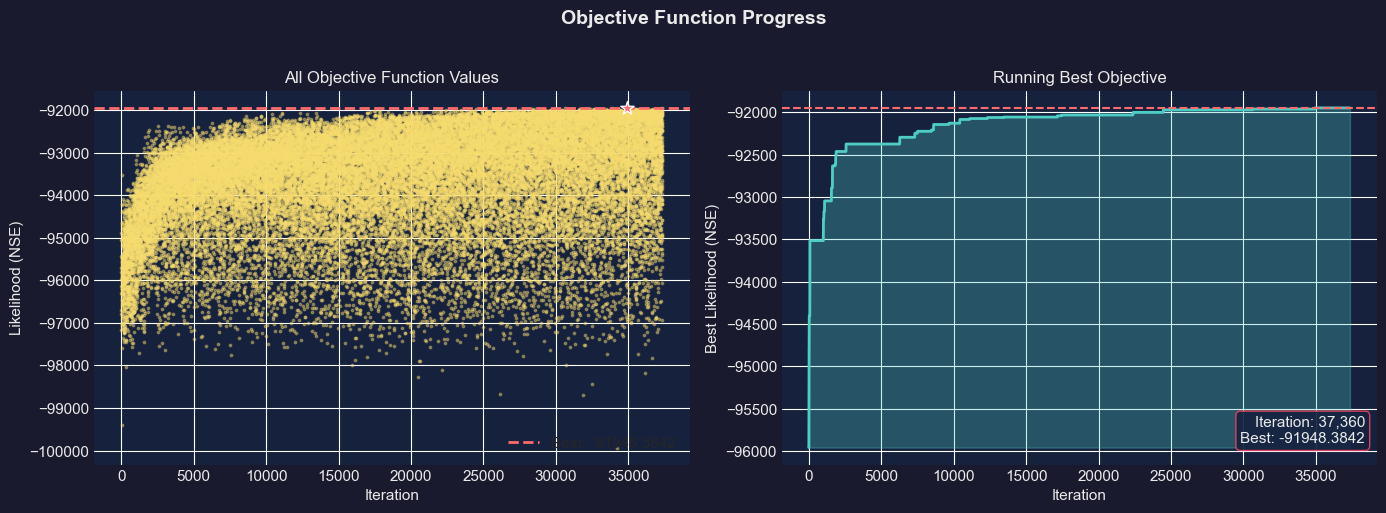

In [ ]:
def plot_objective_progress(df: pd.DataFrame, figsize=(14, 5)):
    """
    Plot objective function progress over iterations.
    
    Shows:
    - Left: All objective values as scatter
    - Right: Running best objective
    """
    if df is None or len(df) == 0:
        print("No data to plot")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    apply_style(fig, np.array([ax1, ax2]))
    
    iterations = df['iteration'].values
    objectives = df['likelihood'].values
    
    # Left: All samples scatter plot
    ax1.scatter(iterations, objectives, alpha=0.4, s=3, c=COLORS['scatter'])
    
    # Mark best
    best_idx = np.argmax(objectives)
    best_val = objectives[best_idx]
    ax1.axhline(y=best_val, color=COLORS['best'], linestyle='--', 
                linewidth=2, label=f'Best: {best_val:.4f}')
    ax1.scatter([best_idx], [best_val], color=COLORS['best'], s=100, 
                zorder=5, marker='*', edgecolor='white')
    
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Likelihood (NSE)')
    ax1.set_title('All Objective Function Values')
    ax1.legend(loc='lower right', facecolor=COLORS['panel'], edgecolor=COLORS['accent'])
    
    # Right: Running best
    running_best = np.maximum.accumulate(objectives)
    ax2.plot(iterations, running_best, color=COLORS['trace'], linewidth=2)
    ax2.fill_between(iterations, running_best.min(), running_best, 
                     alpha=0.3, color=COLORS['trace'])
    ax2.axhline(y=best_val, color=COLORS['best'], linestyle='--', linewidth=1.5)
    
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Best Likelihood (NSE)')
    ax2.set_title('Running Best Objective')
    
    # Add progress annotation
    current_iter = len(df)
    ax2.annotate(f'Iteration: {current_iter:,}\nBest: {best_val:.4f}',
                xy=(0.98, 0.05), xycoords='axes fraction',
                ha='right', va='bottom',
                fontsize=11, color=COLORS['text'],
                bbox=dict(boxstyle='round', facecolor=COLORS['panel'], 
                         edgecolor=COLORS['accent'], alpha=0.9))
    
    plt.suptitle('Objective Function Progress', fontsize=14, fontweight='bold',
                 color=COLORS['text'], y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig


# Plot if data is loaded
if calib_df is not None:
    plot_objective_progress(calib_df)

---
## 2. Dotty Plots (Parameter Sensitivity)

Dotty plots show the relationship between each parameter value and the objective
function. This helps identify:
- **Sensitive parameters**: Clear patterns/peaks in the scatter
- **Insensitive parameters**: Uniform scatter regardless of parameter value
- **Identifiability issues**: Multiple peaks or flat regions

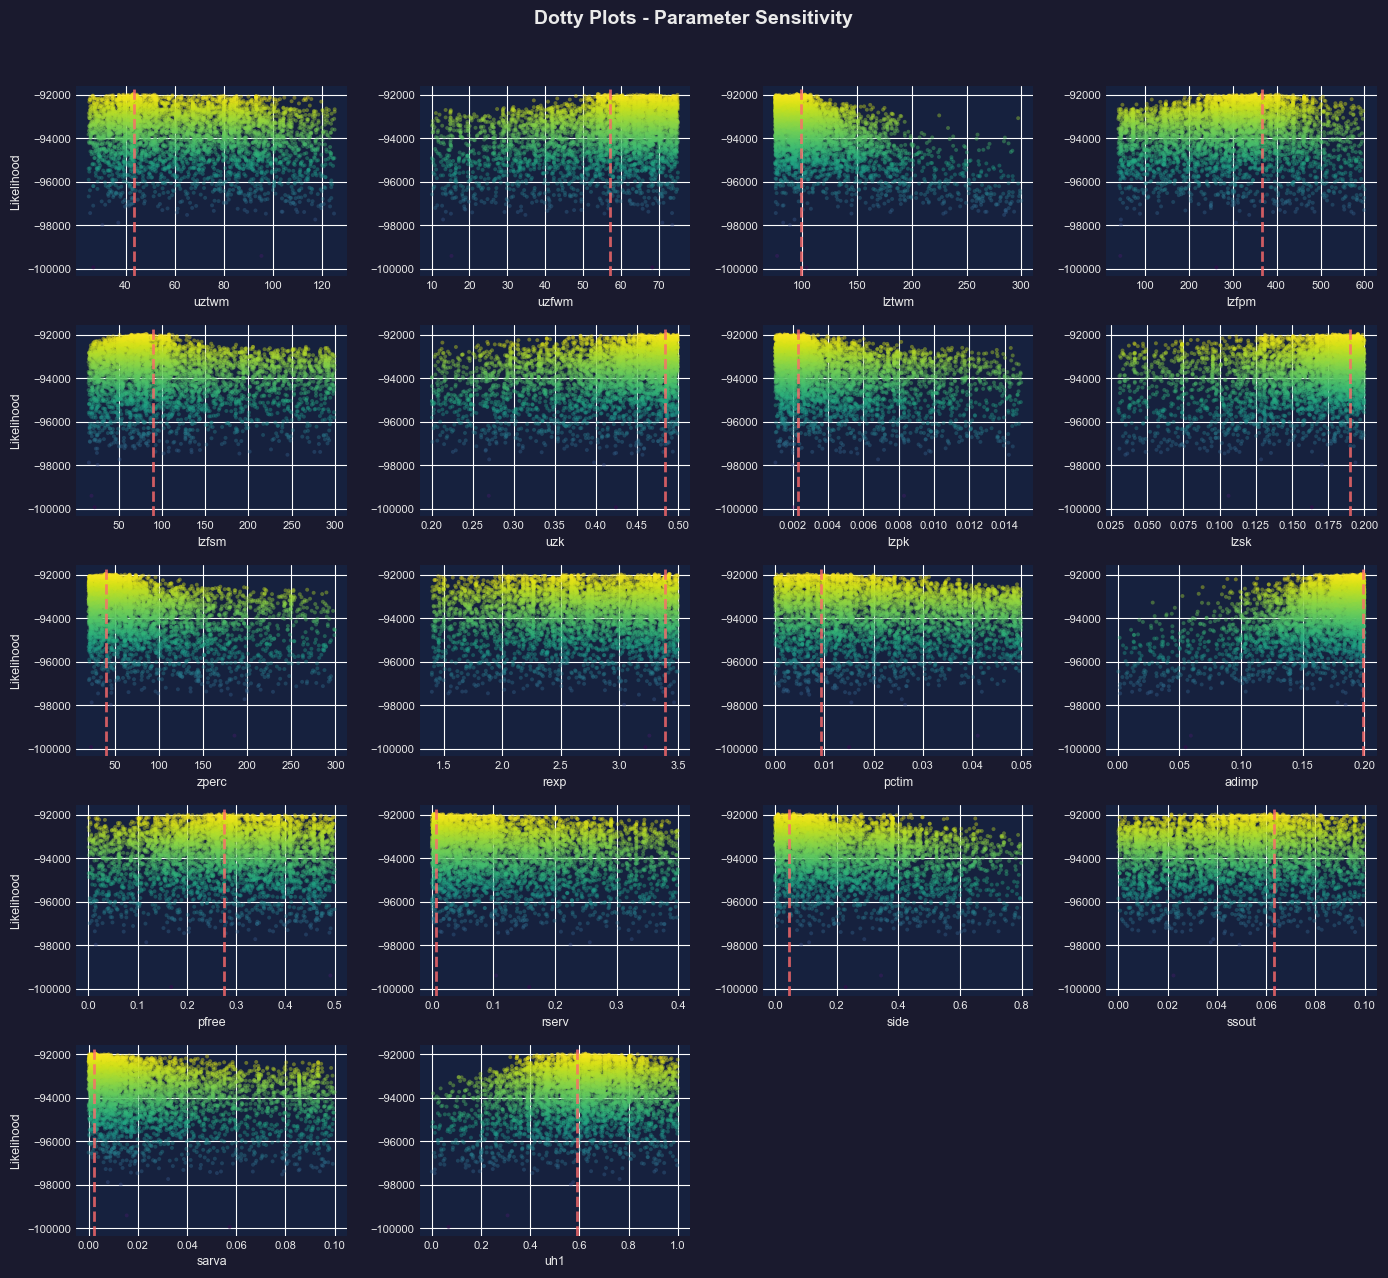

In [ ]:
def plot_dotty_plots(df: pd.DataFrame, params: list = None, 
                     max_params: int = MAX_PARAMS_TO_SHOW,
                     sample_size: int = DOTTY_SAMPLE_SIZE,
                     figsize: tuple = None):
    """
    Create dotty plots showing parameter vs objective function.
    
    Args:
        df: Calibration DataFrame
        params: List of parameters to plot (None for all)
        max_params: Maximum number of parameters to show
        sample_size: Downsample if more samples than this
        figsize: Figure size
    """
    if df is None or len(df) == 0:
        print("No data to plot")
        return
    
    if params is None:
        params = [col for col in df.columns 
                  if col not in ['iteration', 'likelihood']]
    
    params = params[:max_params]
    n_params = len(params)
    
    # Grid layout
    n_cols = min(4, n_params)
    n_rows = int(np.ceil(n_params / n_cols))
    
    if figsize is None:
        figsize = (3.5 * n_cols, 2.5 * n_rows)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.atleast_2d(axes).flatten()
    apply_style(fig, axes)
    
    # Downsample if needed
    if len(df) > sample_size:
        plot_df = df.sample(n=sample_size, random_state=42)
    else:
        plot_df = df
    
    objectives = plot_df['likelihood'].values
    best_idx = df['likelihood'].idxmax()
    
    # Normalize objectives for coloring
    obj_norm = (objectives - objectives.min()) / (objectives.max() - objectives.min() + 1e-10)
    
    for i, (ax, param) in enumerate(zip(axes[:n_params], params)):
        if param in plot_df.columns:
            values = plot_df[param].values
            
            # Scatter with color by objective
            scatter = ax.scatter(values, objectives, c=obj_norm, 
                                cmap='viridis', alpha=0.4, s=8, 
                                edgecolor='none')
            
            # Mark best value
            best_val = df.loc[best_idx, param]
            ax.axvline(x=best_val, color=COLORS['best'], linestyle='--', 
                      linewidth=2, alpha=0.8)
            
            ax.set_xlabel(param, fontsize=9)
            if i % n_cols == 0:
                ax.set_ylabel('Likelihood', fontsize=9)
            
            ax.tick_params(labelsize=8)
    
    # Hide empty axes
    for ax in axes[n_params:]:
        ax.set_visible(False)
    
    plt.suptitle('Dotty Plots - Parameter Sensitivity', fontsize=14, 
                 fontweight='bold', color=COLORS['text'], y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig


# Plot if data is loaded
if calib_df is not None:
    plot_dotty_plots(calib_df)

---
## 3. Parameter Traces (MCMC Chain Evolution)

For MCMC methods like DREAM, the trace plots show how each parameter's
sampled value evolves over iterations. Good mixing shows:
- **Stationary behavior**: Values oscillate around a stable mean
- **Good mixing**: Chains explore the parameter space freely
- **Convergence**: Later iterations should be stable

Poor mixing (stuck chains, trends) indicates convergence problems.

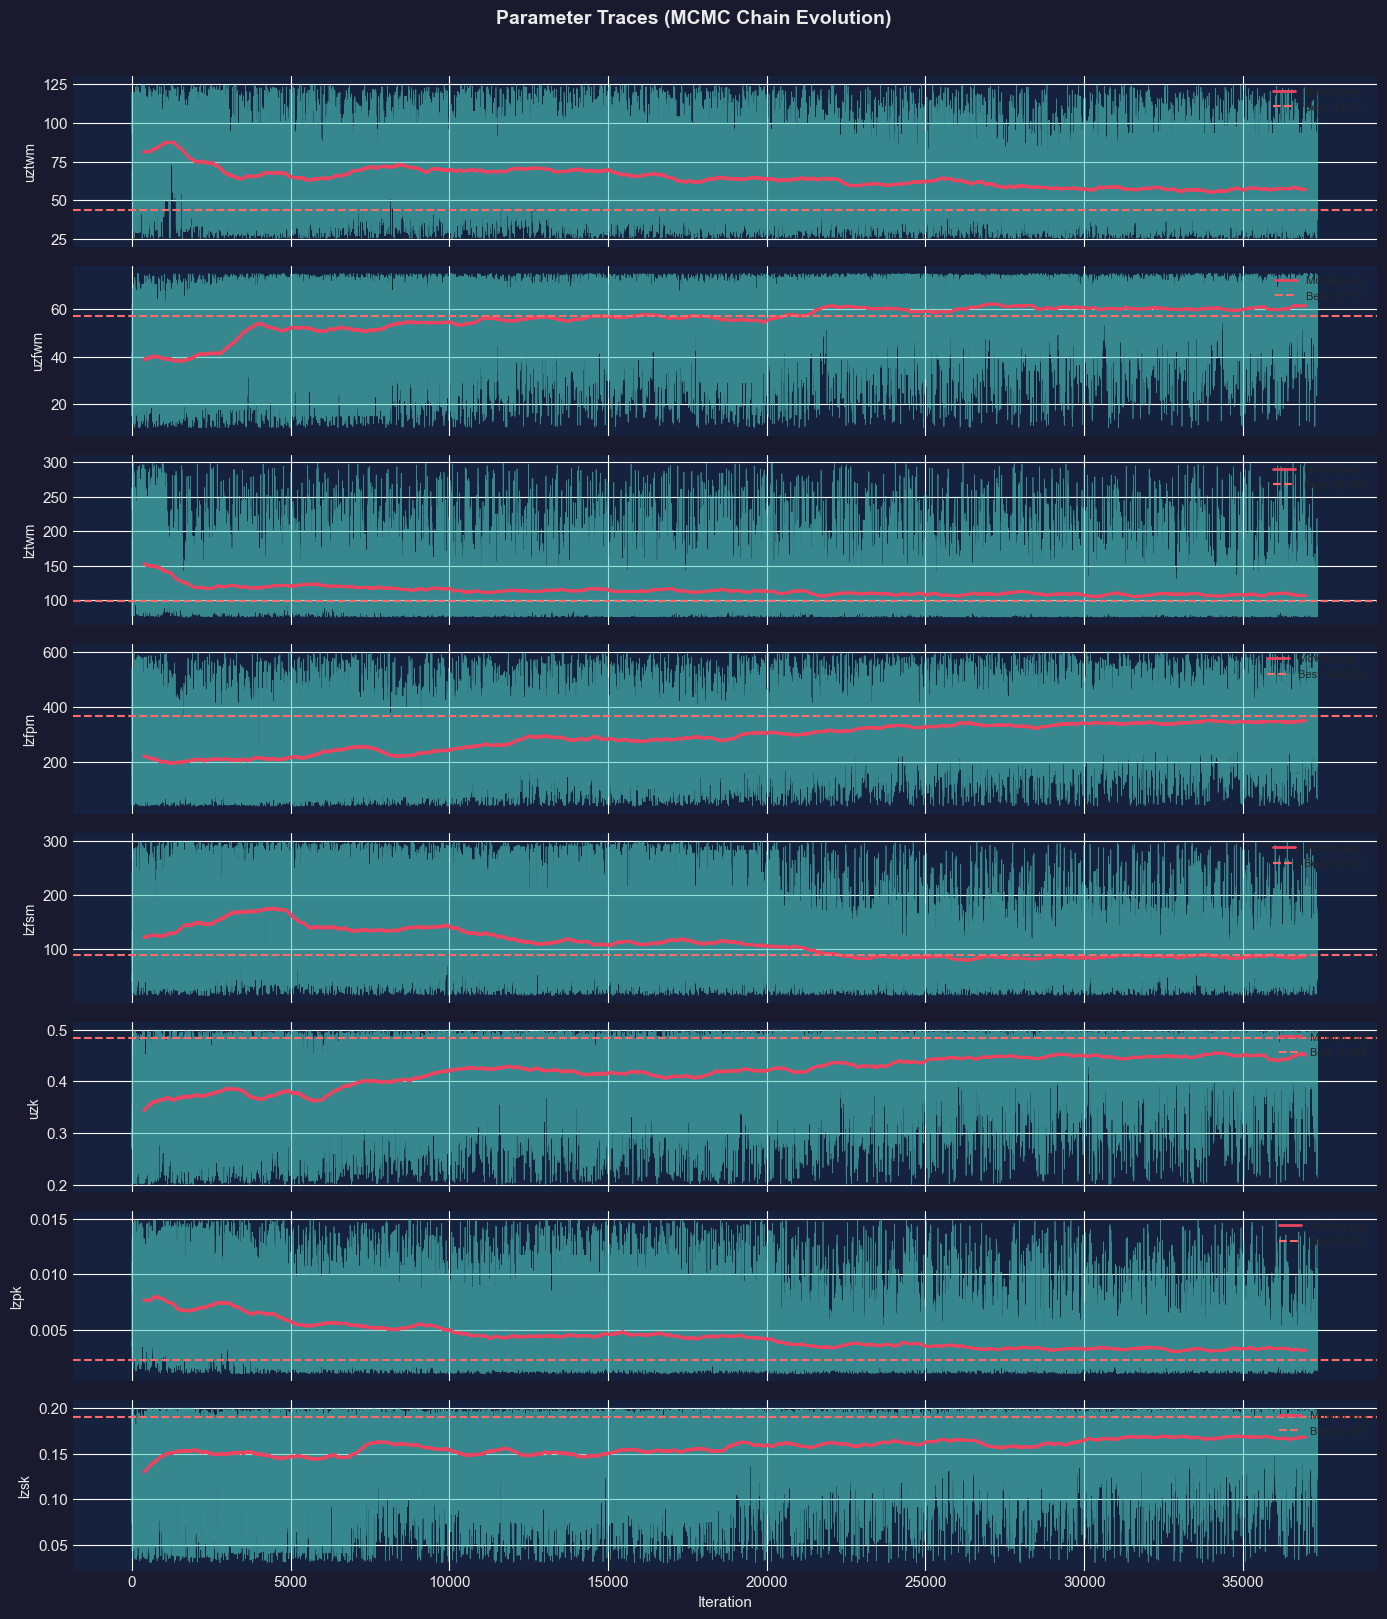

In [ ]:
def plot_parameter_traces(df: pd.DataFrame, params: list = None,
                          max_params: int = MAX_PARAMS_TO_SHOW,
                          figsize: tuple = None):
    """
    Plot parameter traces over iterations.
    
    Args:
        df: Calibration DataFrame
        params: Parameters to plot (None for all)
        max_params: Maximum parameters to show
        figsize: Figure size
    """
    if df is None or len(df) == 0:
        print("No data to plot")
        return
    
    if params is None:
        params = [col for col in df.columns 
                  if col not in ['iteration', 'likelihood']]
    
    params = params[:max_params]
    n_params = len(params)
    
    if figsize is None:
        figsize = (14, 2 * n_params)
    
    fig, axes = plt.subplots(n_params, 1, figsize=figsize, sharex=True)
    if n_params == 1:
        axes = [axes]
    
    apply_style(fig, np.array(axes))
    
    iterations = df['iteration'].values
    best_idx = df['likelihood'].idxmax()
    
    for ax, param in zip(axes, params):
        if param in df.columns:
            values = df[param].values
            
            # Plot trace
            ax.plot(iterations, values, color=COLORS['trace'], 
                   alpha=0.6, linewidth=0.5)
            
            # Add moving average
            window = max(len(values) // 50, 10)
            if len(values) > window:
                ma = pd.Series(values).rolling(window=window, center=True).mean()
                ax.plot(iterations, ma, color=COLORS['accent'], 
                       linewidth=2, label='Moving avg')
            
            # Mark best value
            best_val = df.loc[best_idx, param]
            ax.axhline(y=best_val, color=COLORS['best'], linestyle='--',
                      linewidth=1.5, label=f'Best: {best_val:.3f}')
            
            ax.set_ylabel(param, fontsize=10)
            ax.legend(loc='upper right', fontsize=8, 
                     facecolor=COLORS['panel'], edgecolor=COLORS['accent'])
    
    axes[-1].set_xlabel('Iteration', fontsize=11)
    
    plt.suptitle('Parameter Traces (MCMC Chain Evolution)', fontsize=14,
                 fontweight='bold', color=COLORS['text'], y=1.01)
    plt.tight_layout()
    plt.show()
    
    return fig


# Plot if data is loaded
if calib_df is not None:
    # Show first 8 parameters for clarity
    params_to_show = param_names[:8] if len(param_names) > 8 else param_names
    plot_parameter_traces(calib_df, params=params_to_show)

---
## 4. Posterior Distributions

Show the evolving posterior distributions of parameters. Use the burn-in
slider to exclude early samples (before the chains converge).

**Interpretation:**
- **Narrow peaks**: Well-identified parameters
- **Wide/flat**: Poorly identified parameters
- **Multiple modes**: Equifinality issues

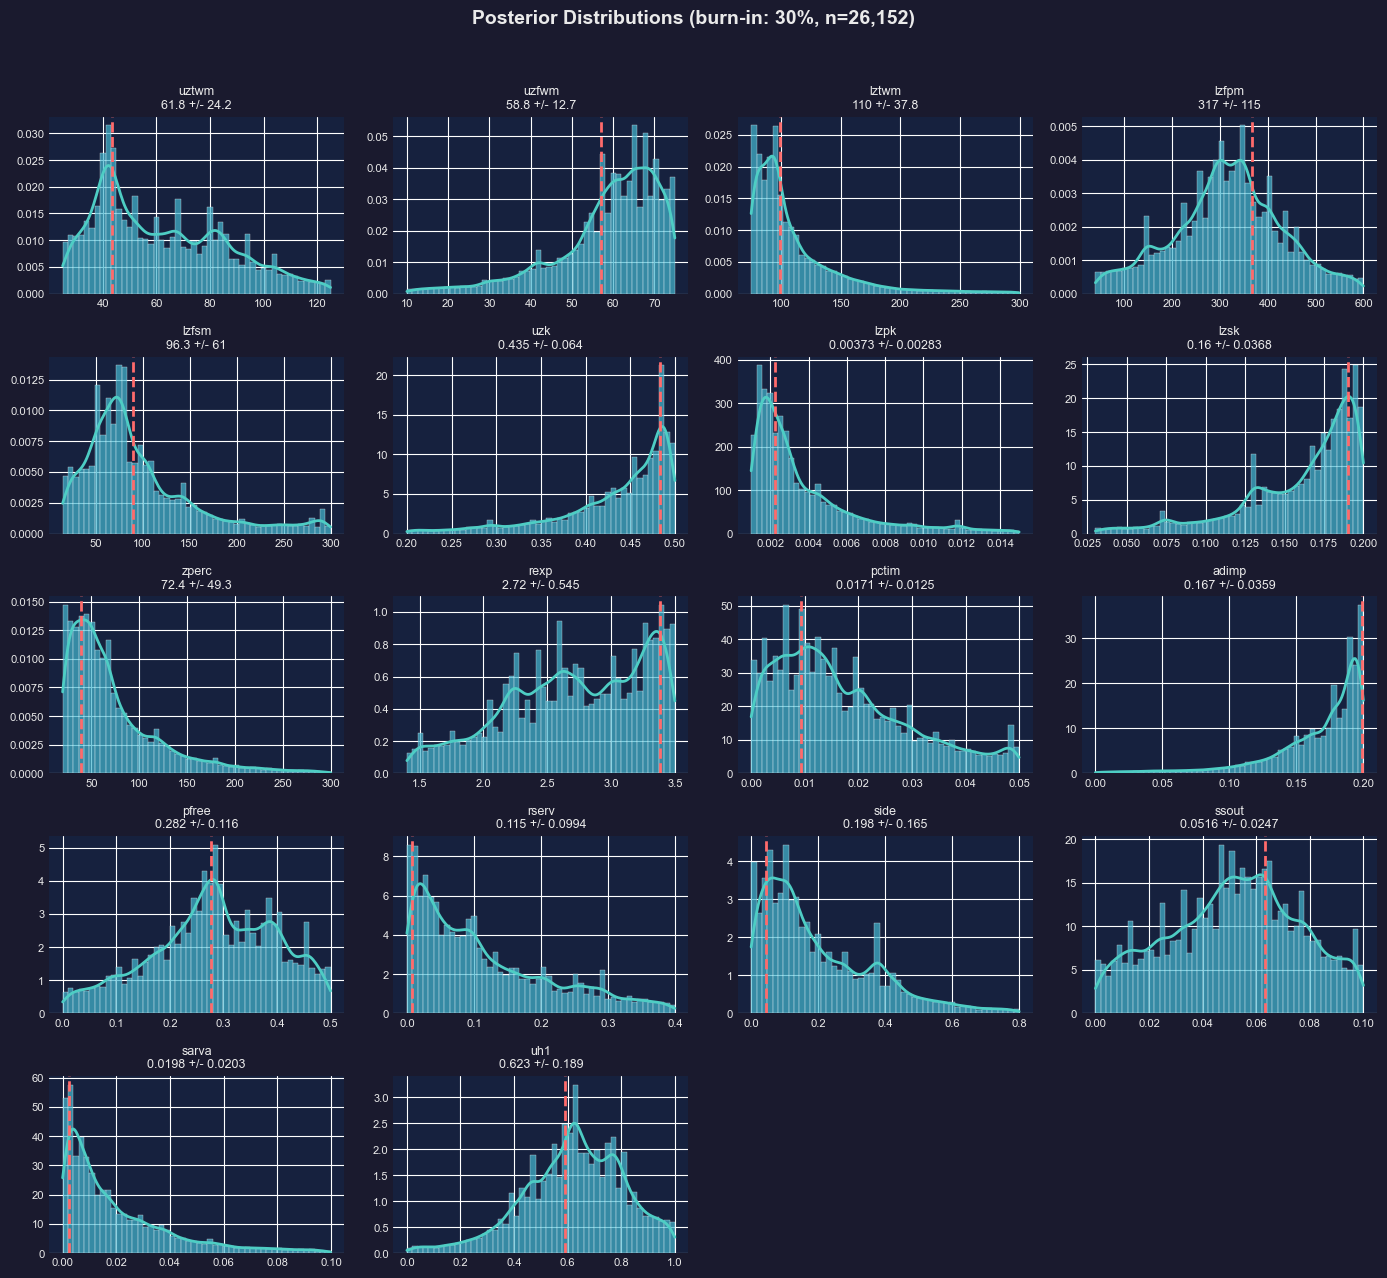

In [ ]:
def plot_posterior_distributions(df: pd.DataFrame, params: list = None,
                                  burnin: float = DEFAULT_BURNIN,
                                  max_params: int = MAX_PARAMS_TO_SHOW,
                                  figsize: tuple = None):
    """
    Plot posterior parameter distributions.
    
    Args:
        df: Calibration DataFrame
        params: Parameters to plot
        burnin: Fraction of samples to discard as burn-in (0.0 to 0.9)
        max_params: Maximum parameters to show
        figsize: Figure size
    """
    if df is None or len(df) == 0:
        print("No data to plot")
        return
    
    # Apply burn-in
    n_burnin = int(len(df) * burnin)
    plot_df = df.iloc[n_burnin:].copy()
    
    if len(plot_df) < 10:
        print(f"Too few samples after burn-in ({len(plot_df)}). Reduce burn-in fraction.")
        return
    
    if params is None:
        params = [col for col in df.columns 
                  if col not in ['iteration', 'likelihood']]
    
    params = params[:max_params]
    n_params = len(params)
    
    # Grid layout
    n_cols = min(4, n_params)
    n_rows = int(np.ceil(n_params / n_cols))
    
    if figsize is None:
        figsize = (3.5 * n_cols, 2.5 * n_rows)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.atleast_2d(axes).flatten()
    apply_style(fig, axes)
    
    best_idx = df['likelihood'].idxmax()
    
    for i, (ax, param) in enumerate(zip(axes[:n_params], params)):
        if param in plot_df.columns:
            values = plot_df[param].dropna().values
            
            if len(values) > 0:
                # Histogram
                ax.hist(values, bins=50, density=True, alpha=0.7,
                       color=COLORS['hist'], edgecolor='white', linewidth=0.3)
                
                # KDE
                try:
                    from scipy import stats
                    kde = stats.gaussian_kde(values)
                    x_range = np.linspace(values.min(), values.max(), 200)
                    ax.plot(x_range, kde(x_range), color=COLORS['kde'], linewidth=2)
                except Exception:
                    pass
                
                # Best value
                best_val = df.loc[best_idx, param]
                ax.axvline(x=best_val, color=COLORS['best'], linestyle='--',
                          linewidth=2, label='Best')
                
                # Statistics
                mean_val = np.mean(values)
                std_val = np.std(values)
                ax.set_title(f'{param}\n{mean_val:.3g} +/- {std_val:.3g}', 
                            fontsize=9, color=COLORS['text'])
        
        ax.tick_params(labelsize=8)
    
    # Hide empty axes
    for ax in axes[n_params:]:
        ax.set_visible(False)
    
    title = f'Posterior Distributions (burn-in: {burnin*100:.0f}%, n={len(plot_df):,})'
    plt.suptitle(title, fontsize=14, fontweight='bold', 
                 color=COLORS['text'], y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig


# Plot if data is loaded
if calib_df is not None:
    plot_posterior_distributions(calib_df, burnin=0.3)

---
## 5. Interactive Posterior with Burn-in Control

Use the slider to adjust the burn-in period and see how the posteriors change.

In [ ]:
if WIDGETS_AVAILABLE and calib_df is not None:
    @interact(burnin=FloatSlider(min=0.0, max=0.9, step=0.05, value=0.3,
                                  description='Burn-in:'))
    def interactive_posterior(burnin):
        plot_posterior_distributions(calib_df, burnin=burnin)
else:
    print("Interactive widgets not available or no data loaded.")
    print("Run plot_posterior_distributions(calib_df, burnin=X) manually")

---
## 6. Chain Convergence Diagnostics

For DREAM calibrations with multiple chains, assess convergence using
visual inspection and statistical measures.

In [ ]:
def plot_likelihood_by_chain(df: pd.DataFrame, n_chains: int = 5,
                              figsize: tuple = (14, 6)):
    """
    Attempt to visualize likelihood evolution by chain.
    
    Note: SpotPy interleaves chain samples, so we reshape assuming
    samples are written chain-by-chain in sequence.
    
    Args:
        df: Calibration DataFrame
        n_chains: Number of chains used in DREAM
        figsize: Figure size
    """
    if df is None or len(df) == 0:
        print("No data to plot")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    apply_style(fig, np.array([ax1, ax2]))
    
    objectives = df['likelihood'].values
    n_samples = len(objectives)
    
    # Try to reshape into chains (assumes interleaved sampling)
    samples_per_chain = n_samples // n_chains
    if samples_per_chain > 0:
        # Interleaved: sample 0 from chain 0, sample 1 from chain 1, etc.
        chain_colors = plt.cm.tab10(np.linspace(0, 1, n_chains))
        
        for chain_idx in range(n_chains):
            chain_samples = objectives[chain_idx::n_chains][:samples_per_chain]
            iterations = np.arange(len(chain_samples))
            
            ax1.plot(iterations, chain_samples, alpha=0.6, linewidth=0.8,
                    color=chain_colors[chain_idx], label=f'Chain {chain_idx+1}')
            
            # Running mean
            if len(chain_samples) > 20:
                window = max(len(chain_samples) // 20, 5)
                running_mean = pd.Series(chain_samples).rolling(window).mean()
                ax2.plot(iterations, running_mean, linewidth=2,
                        color=chain_colors[chain_idx], label=f'Chain {chain_idx+1}')
    
    ax1.set_xlabel('Iteration (within chain)')
    ax1.set_ylabel('Likelihood')
    ax1.set_title('Raw Chain Samples')
    ax1.legend(loc='lower right', fontsize=8,
              facecolor=COLORS['panel'], edgecolor=COLORS['accent'])
    
    ax2.set_xlabel('Iteration (within chain)')
    ax2.set_ylabel('Running Mean Likelihood')
    ax2.set_title('Chain Running Means')
    ax2.legend(loc='lower right', fontsize=8,
              facecolor=COLORS['panel'], edgecolor=COLORS['accent'])
    
    plt.suptitle('Chain Evolution (assuming interleaved sampling)', 
                 fontsize=14, fontweight='bold', color=COLORS['text'], y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig


def estimate_gelman_rubin(df: pd.DataFrame, param: str, n_chains: int = 5) -> float:
    """
    Estimate Gelman-Rubin R-hat statistic for a parameter.
    
    R-hat < 1.1 generally indicates convergence.
    
    Args:
        df: Calibration DataFrame
        param: Parameter name
        n_chains: Number of chains
        
    Returns:
        R-hat value (np.nan if cannot compute)
    """
    if param not in df.columns:
        return np.nan
    
    values = df[param].values
    n_samples = len(values)
    samples_per_chain = n_samples // n_chains
    
    if samples_per_chain < 10:
        return np.nan
    
    # Reshape into chains (assuming interleaved)
    chains = []
    for chain_idx in range(n_chains):
        chain_samples = values[chain_idx::n_chains][:samples_per_chain]
        # Use second half for Gelman-Rubin
        half_point = len(chain_samples) // 2
        chains.append(chain_samples[half_point:])
    
    chains = np.array(chains)
    
    # Gelman-Rubin calculation
    n = chains.shape[1]  # samples per chain
    m = chains.shape[0]  # number of chains
    
    # Within-chain variance
    W = np.mean(np.var(chains, axis=1, ddof=1))
    
    # Between-chain variance
    chain_means = np.mean(chains, axis=1)
    B = n * np.var(chain_means, ddof=1)
    
    # Pooled variance estimate
    var_estimate = ((n - 1) / n) * W + (1 / n) * B
    
    # R-hat
    if W > 0:
        r_hat = np.sqrt(var_estimate / W)
    else:
        r_hat = np.nan
    
    return r_hat


def print_convergence_diagnostics(df: pd.DataFrame, params: list = None, 
                                   n_chains: int = 5):
    """Print Gelman-Rubin convergence diagnostics."""
    if df is None:
        print("No data available")
        return
    
    if params is None:
        params = [col for col in df.columns 
                  if col not in ['iteration', 'likelihood']]
    
    print(f"\n{'='*60}")
    print("GELMAN-RUBIN CONVERGENCE DIAGNOSTICS")
    print(f"{'='*60}")
    print(f"Samples: {len(df):,} | Assumed chains: {n_chains}")
    print(f"\nR-hat < 1.1 indicates convergence")
    print(f"R-hat < 1.05 indicates good convergence")
    print(f"{'-'*60}")
    print(f"{'Parameter':20s} {'R-hat':>10s} {'Status':>15s}")
    print(f"{'-'*60}")
    
    converged = 0
    for param in params[:MAX_PARAMS_TO_SHOW]:
        r_hat = estimate_gelman_rubin(df, param, n_chains)
        
        if np.isnan(r_hat):
            status = "N/A"
        elif r_hat < 1.05:
            status = "Converged"
            converged += 1
        elif r_hat < 1.1:
            status = "OK"
            converged += 1
        elif r_hat < 1.2:
            status = "Borderline"
        else:
            status = "Not converged"
        
        r_hat_str = f"{r_hat:.4f}" if not np.isnan(r_hat) else "N/A"
        print(f"{param:20s} {r_hat_str:>10s} {status:>15s}")
    
    print(f"{'-'*60}")
    print(f"Converged parameters: {converged}/{len(params[:MAX_PARAMS_TO_SHOW])}")


# Show diagnostics if data is loaded
if calib_df is not None:
    plot_likelihood_by_chain(calib_df, n_chains=5)
    print_convergence_diagnostics(calib_df, param_names, n_chains=5)

---
## 7. Refresh Data

Use this cell to reload the CSV file and update all plots.
Useful for monitoring ongoing calibrations.

In [ ]:
def refresh_and_plot():
    """Reload data and regenerate all plots."""
    global raw_df, calib_df, param_names, stats
    
    print(f"\n{'='*60}")
    print(f"REFRESHING DATA - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*60}\n")
    
    try:
        raw_df = load_calibration_data(CSV_FILE)
        param_names_new, obj_col, calib_df = extract_parameters(raw_df)
        param_names = param_names_new
        stats = get_calibration_stats(calib_df, param_names)
        
        print(f"\nProgress: {stats['n_samples']:,} samples | Best: {stats['best_likelihood']:.6f}")
        
        # Regenerate plots
        print("\n1. Objective Progress")
        plot_objective_progress(calib_df)
        
        print("\n2. Dotty Plots")
        plot_dotty_plots(calib_df)
        
        print("\n3. Parameter Traces (first 8)")
        params_to_show = param_names[:8] if len(param_names) > 8 else param_names
        plot_parameter_traces(calib_df, params=params_to_show)
        
        print("\n4. Posterior Distributions")
        plot_posterior_distributions(calib_df, burnin=0.3)
        
        print("\n5. Convergence Diagnostics")
        print_convergence_diagnostics(calib_df, param_names, n_chains=5)
        
    except Exception as e:
        print(f"ERROR: {e}")
        import traceback
        traceback.print_exc()


# Run refresh once to show current state
# Uncomment the line below to manually refresh:
# refresh_and_plot()

---
## 8. Auto-Refresh Mode

Enable automatic refresh every N seconds to continuously monitor progress.
**Warning**: This will continuously reload and replot - use for active monitoring only.

In [ ]:
def auto_refresh(interval_seconds: int = 30, max_refreshes: int = 100):
    """
    Automatically refresh and replot at regular intervals.
    
    Args:
        interval_seconds: Seconds between refreshes
        max_refreshes: Maximum number of refreshes before stopping
        
    Press Kernel > Interrupt to stop early.
    """
    print(f"Starting auto-refresh every {interval_seconds} seconds...")
    print("Press Kernel > Interrupt to stop\n")
    
    for i in range(max_refreshes):
        try:
            clear_output(wait=True)
            print(f"Auto-refresh #{i+1} of {max_refreshes}")
            refresh_and_plot()
            print(f"\nNext refresh in {interval_seconds} seconds...")
            time.sleep(interval_seconds)
        except KeyboardInterrupt:
            print("\nAuto-refresh stopped by user.")
            break
    
    print("Auto-refresh completed.")


# Uncomment to enable auto-refresh (30 second intervals):
# auto_refresh(interval_seconds=30, max_refreshes=50)

---
## 9. Export Best Parameters

Export the current best parameters to use in your model.

In [ ]:
def export_best_parameters():
    """Print best parameters in formats ready for use."""
    if calib_df is None:
        print("No data loaded")
        return
    
    stats = get_calibration_stats(calib_df, param_names)
    
    print(f"\n{'='*60}")
    print("EXPORT BEST PARAMETERS")
    print(f"{'='*60}")
    print(f"Best likelihood: {stats['best_likelihood']:.6f}")
    print(f"Sample #{stats['best_idx']:,}")
    
    print(f"\n{'='*60}")
    print("Python Dictionary Format:")
    print(f"{'='*60}")
    print("best_params = {")
    for param, value in stats['best_params'].items():
        print(f"    '{param}': {value:.8f},")
    print("}")
    
    print(f"\n{'='*60}")
    print("For pyrrm model.set_parameters():")
    print(f"{'='*60}")
    params_str = ", ".join([f"'{k}': {v:.6f}" for k, v in stats['best_params'].items()])
    print(f"model.set_parameters({{{params_str}}})")


# Export if data is loaded
if calib_df is not None:
    export_best_parameters()

---
## 10. Parameter Correlation Matrix

Visualize correlations between parameters in the posterior distribution.

In [ ]:
def plot_parameter_correlations(df: pd.DataFrame, params: list = None,
                                 burnin: float = 0.5,
                                 max_params: int = 12,
                                 figsize: tuple = None):
    """
    Plot parameter correlation matrix from posterior samples.
    
    Args:
        df: Calibration DataFrame
        params: Parameters to include
        burnin: Burn-in fraction
        max_params: Maximum parameters to show
        figsize: Figure size
    """
    if df is None or len(df) == 0:
        print("No data to plot")
        return
    
    # Apply burn-in
    n_burnin = int(len(df) * burnin)
    plot_df = df.iloc[n_burnin:].copy()
    
    if params is None:
        params = [col for col in df.columns 
                  if col not in ['iteration', 'likelihood']]
    
    params = params[:max_params]
    
    # Calculate correlation matrix
    corr_data = plot_df[params].corr()
    
    if figsize is None:
        figsize = (max(8, len(params) * 0.6), max(6, len(params) * 0.5))
    
    fig, ax = plt.subplots(figsize=figsize)
    apply_style(fig, ax)
    
    # Plot heatmap
    im = ax.imshow(corr_data.values, cmap='RdBu_r', vmin=-1, vmax=1)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Correlation', color=COLORS['text'])
    cbar.ax.yaxis.set_tick_params(color=COLORS['text'])
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=COLORS['text'])
    
    # Labels
    ax.set_xticks(np.arange(len(params)))
    ax.set_yticks(np.arange(len(params)))
    ax.set_xticklabels(params, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(params, fontsize=9)
    
    # Add correlation values
    for i in range(len(params)):
        for j in range(len(params)):
            val = corr_data.iloc[i, j]
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                   color=color, fontsize=8)
    
    ax.set_title(f'Parameter Correlations (burn-in: {burnin*100:.0f}%)',
                fontsize=12, color=COLORS['text'])
    
    plt.tight_layout()
    plt.show()
    
    return fig


# Plot if data is loaded
if calib_df is not None:
    # Show correlations for first 12 parameters
    plot_parameter_correlations(calib_df, params=param_names[:12], burnin=0.5)

---
## Summary

This notebook provides real-time monitoring of SpotPy-DREAM calibrations.

**Key functions:**
- `load_calibration_data(csv_path)` - Load SpotPy CSV output
- `plot_objective_progress(df)` - Objective function evolution
- `plot_dotty_plots(df)` - Parameter sensitivity
- `plot_parameter_traces(df)` - MCMC chain evolution
- `plot_posterior_distributions(df, burnin)` - Parameter distributions
- `print_convergence_diagnostics(df, params, n_chains)` - Gelman-Rubin R-hat
- `refresh_and_plot()` - Reload data and update all plots
- `auto_refresh(interval_seconds)` - Continuous monitoring mode

**Tips:**
- Start with `burnin=0.0` early in calibration, increase to `0.3-0.5` later
- R-hat < 1.1 indicates convergence, < 1.05 is ideal
- Wide posteriors suggest poorly identified parameters
- Multiple peaks in posteriors indicate equifinality

In [ ]:
print(f"\nCalibration Monitor session completed.")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")